# 08 - GRDC Gauge Comparison

Load observed daily streamflow from the Global Runoff Data Center (GRDC) and compare with Google GRRR reanalysis and GloFAS data.

**Inputs (from Azure):**
- `ds-aa-nga-flooding/raw/grdc/GRDC-Daily.nc` — GRDC daily discharge
- `ds-aa-nga-flooding/raw/grdc/stationbasins.geojson` — GRDC station basins

In [159]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [160]:
import tempfile

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import xarray as xr
from dotenv import load_dotenv

from src.datasources import nihsa, grrr

load_dotenv()

gauge_mapping = {
    # Makurdi
    1835020: "hybas_1120911340",
    # Umaisha
    1835025: "hybas_1120904190",
    # Lokoja
    1834101: "hybas_1120908000", # or maybe: hybas_1120909890
    # Kende
    1834010: "hybas_1120750570",
    # Yidere bode
    1834110: "hybas_1120755820",
    # Wuro boki
    1835010: "hybas_1121971560", # or maybe: hybas_1120842550
    # Ibi
    1835900: "hybas_1120887720",
    # Baro
    1834015: "hybas_1120870480",
    # Onitsha
    1834020: "hybas_1120975380" # not qa
}

In [161]:
gdf_rivers = stratus.load_shp_from_blob("ds-aa-nga-flooding/raw/AA-nigeria_data/OCHA/benue_niger.zip", shapefile="NGA_rvrsl_1m_esri.shp")
gdf_hydrological_areas = nihsa.load_hydological_areas()

## Load data

In [162]:
# Load GRDC daily discharge NetCDF from Azure
container_client = stratus.get_container_client("projects", stage="dev")
nc_bytes = container_client.get_blob_client("ds-aa-nga-flooding/raw/grdc/GRDC-Daily.nc").download_blob().readall()

with tempfile.NamedTemporaryFile(suffix=".nc", delete=False) as tmp:
    tmp.write(nc_bytes)
    tmp_path = tmp.name

ds_grdc = xr.open_dataset(tmp_path)
ds_grdc

<xarray.Dataset> Size: 5MB
Dimensions:              (time: 24303, id: 54)
Coordinates:
  * time                 (time) datetime64[ns] 194kB 1958-06-19 ... 2024-12-31
  * id                   (id) int64 432B 1834010 1834015 ... 1837801 1837810
Data variables:
    runoff_mean          (time, id) float32 5MB ...
    area                 (id) float32 216B ...
    country              (id) <U2 432B ...
    geo_x                (id) float32 216B ...
    geo_y                (id) float32 216B ...
    geo_z                (id) float32 216B ...
    owneroforiginaldata  (id) <U42 9kB ...
    river_name           (id) <U15 3kB ...
    station_name         (id) <U28 6kB ...
    timezone             (id) float32 216B ...
Attributes:
    title:          Mean daily discharge (Q)
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Download from GRDC Database, 11/03/2026
    missing_value:  -999.000

## Map: GRDC gauge locations and basins

In [163]:
# Build point GeoDataFrame from dataset coordinates, filtered to gauge_mapping keys
station_ids = ds_grdc["id"].values
lons = ds_grdc["geo_x"].values
lats = ds_grdc["geo_y"].values
station_names = ds_grdc["station_name"].values
data_owner = ds_grdc["owneroforiginaldata"].values

gdf_stations_all = gpd.GeoDataFrame(
    {"station_id":station_ids, "station_name": station_names, "data_owner": data_owner},
    geometry=gpd.points_from_xy(lons, lats),
    crs="EPSG:4326",
)

# Filter to only gauges in gauge_mapping
mapped_grdc_ids = list(gauge_mapping.keys())
gdf_stations = gdf_stations_all[gdf_stations_all["station_id"].isin(mapped_grdc_ids)].copy()
print(f"All gauge stations: {len(gdf_stations_all)}")
print(f"Mapped gauge stations: {len(gdf_stations)}")

All gauge stations: 54
Mapped gauge stations: 9


In [164]:
gdf_stations

,station_id,station_name,data_owner,geometry
0,1834010,KENDE,Niger - Niger Basin Authority (NBA),POINT (4.25057 11.52278)
1,1834015,BARO,Niger - Niger Basin Authority (NBA),POINT (6.383 8.583)
2,1834020,ONITSHA,Niger - Niger Basin Authority (NBA),POINT (6.77548 6.1625)
4,1834101,LOKOJA,Niger - Niger Basin Authority (NBA),POINT (6.7667 7.8)
5,1834110,YIDERE BODE,Niger - Niger Basin Authority (NBA),POINT (4.1333 11.3833)
6,1835010,WURO BOKI,Niger - Niger Basin Authority (NBA),POINT (12.79327 9.38439)
8,1835020,MAKURDI,Niger - Niger Basin Authority (NBA),POINT (8.53213 7.74618)
9,1835025,UMAISHA,Niger - Niger Basin Authority (NBA),POINT (7.18451 8.00275)
10,1835900,IBI,Niger - Niger Basin Authority (NBA),POINT (9.7333 8.2)


In [165]:
locations_path = (
    "gs://flood-forecasting/hydrologic_predictions/model_id_8583a5c2_v0/"
    "hybas_outlet_locations_UNOFFICIAL.zarr/"
)
ds_locs = grrr.open_zarr(locations_path)
google_gauge_ids = list(gauge_mapping.values())
ds_locs_sel = ds_locs.sel(gauge_id=google_gauge_ids).compute()

gdf_google = gpd.GeoDataFrame(
    {"gauge_id": ds_locs_sel["gauge_id"].values},
    geometry=gpd.points_from_xy(
        ds_locs_sel["longitude"].values,
        ds_locs_sel["latitude"].values,
    ),
    crs="EPSG:4326",
)

# Build a lookup from google gauge_id -> grdc station name for labelling
google_to_name = {v: gdf_stations.set_index("station_id")["station_name"].get(k, k)
                  for k, v in gauge_mapping.items()}
gdf_google["station_name"] = gdf_google["gauge_id"].map(google_to_name)

print(f"Google gauges loaded: {len(gdf_google)}")

Google gauges loaded: 9


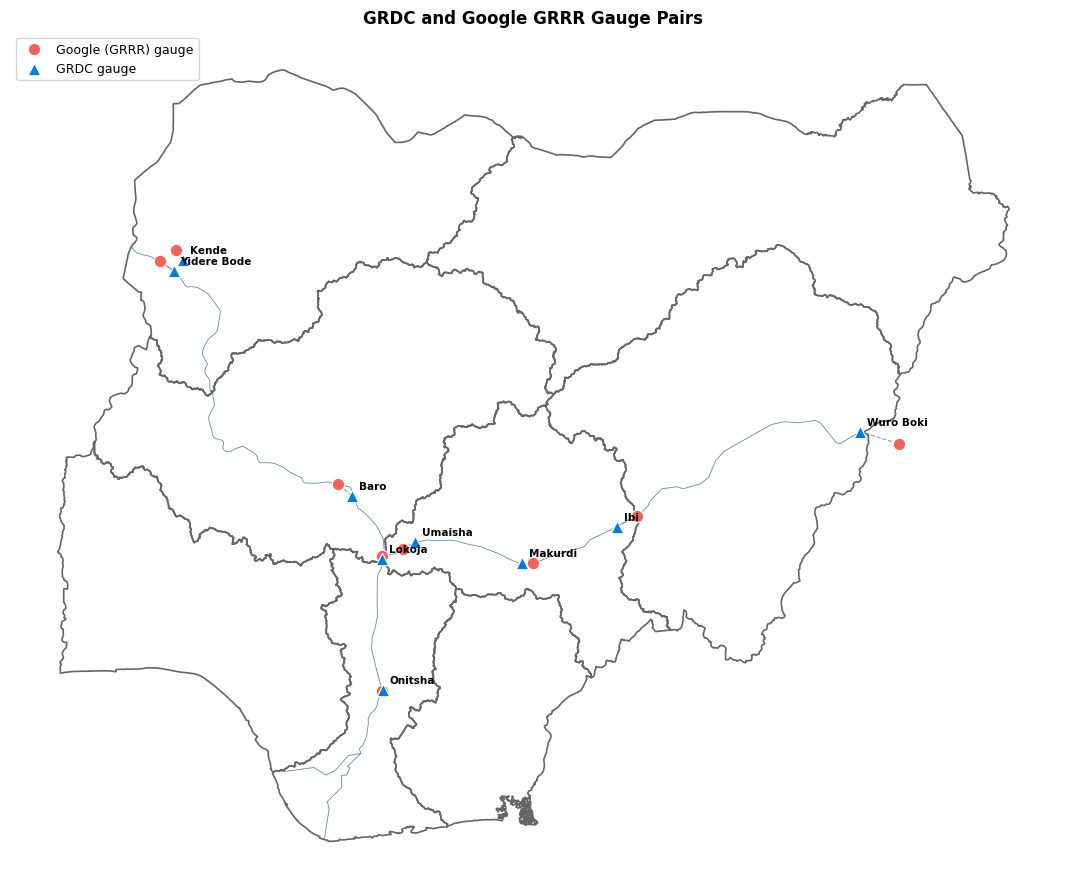

In [166]:
fig, ax = plt.subplots(figsize=(11, 9))

# Rivers and HA boundaries
gdf_rivers.plot(ax=ax, color="#1E5A8E", linewidth=0.6, alpha=0.7, zorder=1)
if gdf_hydrological_areas.crs is None:
    gdf_hydrological_areas = gdf_hydrological_areas.set_crs(epsg=4326)
gdf_hydrological_areas.boundary.plot(ax=ax, color="#666666", linewidth=1.2, zorder=2)

# Google gauges
gdf_google.plot(
    ax=ax, color="#F2645A", markersize=80, marker="o",
    edgecolor="white", linewidth=0.8, zorder=4, label="Google (GRRR) gauge"
)

# GRDC gauges
gdf_stations.plot(
    ax=ax, color="#007CE0", markersize=80, marker="^",
    edgecolor="white", linewidth=0.8, zorder=5, label="GRDC gauge"
)

# Draw lines connecting each GRDC–Google pair and label by station name
for grdc_id, google_id in gauge_mapping.items():
    grdc_row = gdf_stations[gdf_stations["station_id"] == grdc_id]
    google_row = gdf_google[gdf_google["gauge_id"] == google_id]
    if grdc_row.empty or google_row.empty:
        continue
    gx, gy = grdc_row.geometry.iloc[0].x, grdc_row.geometry.iloc[0].y
    ox, oy = google_row.geometry.iloc[0].x, google_row.geometry.iloc[0].y
    ax.plot([gx, ox], [gy, oy], color="#999999", linewidth=0.8, linestyle="--", zorder=3)
    ax.annotate(
        grdc_row["station_name"].iloc[0].title(),
        xy=(gx, gy),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7.5,
        fontweight="bold",
        zorder=6,
    )

ax.legend(loc="upper left", fontsize=9)
ax.set_title("GRDC and Google GRRR Gauge Pairs", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/google_grrr_gauge_locations.png", dpi=300)

## Correlation with Google GRRR Reanalysis

In [167]:
import numpy as np
import pandas as pd
from scipy import stats

from src.datasources import grrr

# Load Google GRRR reanalysis for all mapped gauges
google_gauge_ids = list(gauge_mapping.values())
ds_ra = grrr.load_reanalysis(gauge=google_gauge_ids)
df_ra = grrr.process_reanalysis(ds_ra)
df_ra["date"] = df_ra["valid_time"].dt.normalize()
print(f"Google reanalysis: {df_ra['date'].min().date()} – {df_ra['date'].max().date()}")
print(f"Gauges loaded: {df_ra['gauge_id'].nunique()}")

Google reanalysis: 1980-01-01 – 2023-12-23
Gauges loaded: 9


In [168]:
# Build GRDC daily timeseries in long format, masking -999 missing values
df_grdc = ds_grdc["runoff_mean"].to_dataframe().reset_index()
df_grdc = df_grdc.rename(columns={"time": "date", "id": "grdc_id", "runoff_mean": "grdc_q"})
df_grdc["grdc_q"] = df_grdc["grdc_q"].where(df_grdc["grdc_q"] > -900)
df_grdc["date"] = pd.to_datetime(df_grdc["date"]).dt.normalize()

name_lookup = gdf_stations.set_index("station_id")["station_name"].to_dict()

In [169]:
# Compute Spearman correlation for each GRDC–Google pair over the overlapping period
results = []
pair_data = {}

for grdc_id, google_id in gauge_mapping.items():
    station = name_lookup.get(grdc_id, str(grdc_id))

    grdc_ts = df_grdc[df_grdc["grdc_id"] == grdc_id][["date", "grdc_q"]].dropna()
    google_ts = df_ra[df_ra["gauge_id"] == google_id][["date", "streamflow"]].dropna()

    merged = grdc_ts.merge(google_ts, on="date", how="inner").sort_values("date").reset_index(drop=True)

    if len(merged) < 30:
        print(f"Skipping {station}: only {len(merged)} overlapping days")
        continue

    r, p = stats.spearmanr(merged["grdc_q"], merged["streamflow"])
    results.append({
        "station_name": station,
        "grdc_id": grdc_id,
        "google_id": google_id,
        "n_days": len(merged),
        "date_start": merged["date"].min().date(),
        "date_end": merged["date"].max().date(),
        "spearman_r": round(r, 3),
        "p_value": round(p, 4),
    })
    pair_data[grdc_id] = merged

df_corr = pd.DataFrame(results).sort_values("spearman_r", ascending=False).reset_index(drop=True)
df_corr

,station_name,grdc_id,google_id,n_days,date_start,date_end,spearman_r,p_value
0,IBI,1835900,hybas_1120887720,3653,1980-01-01,2002-10-30,0.892,0.0
1,MAKURDI,1835020,hybas_1120911340,6939,1990-01-01,2023-10-29,0.855,0.0
2,YIDERE BODE,1834110,hybas_1120755820,13268,1984-01-01,2023-12-23,0.855,0.0
3,KENDE,1834010,hybas_1120750570,6110,1990-04-02,2023-12-23,0.826,0.0
4,ONITSHA,1834020,hybas_1120975380,3128,1990-04-17,2017-12-03,0.750,0.0
5,UMAISHA,1835025,hybas_1120904190,3379,1990-01-01,2023-12-23,0.742,0.0
6,LOKOJA,1834101,hybas_1120908000,13893,1980-01-01,2023-12-23,0.694,0.0
7,WURO BOKI,1835010,hybas_1121971560,3722,1991-03-08,2023-12-23,0.545,0.0
8,BARO,1834015,hybas_1120870480,3751,1990-01-01,2023-02-09,0.516,0.0


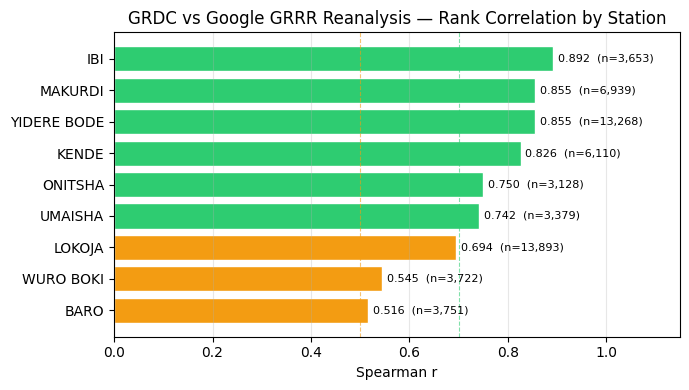

In [170]:
# Summary: horizontal bar chart of Spearman r by station
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#2ecc71" if r >= 0.7 else "#f39c12" if r >= 0.5 else "#e74c3c" for r in df_corr["spearman_r"]]
bars = ax.barh(df_corr["station_name"], df_corr["spearman_r"], color=colors, edgecolor="white")

for bar, r, n in zip(bars, df_corr["spearman_r"], df_corr["n_days"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{r:.3f}  (n={n:,})", va="center", fontsize=8)

ax.axvline(0.7, color="#2ecc71", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(0.5, color="#f39c12", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Spearman r")
ax.set_title("GRDC vs Google GRRR Reanalysis — Rank Correlation by Station")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/grdc_google_spearman_correlation.png", dpi=300)

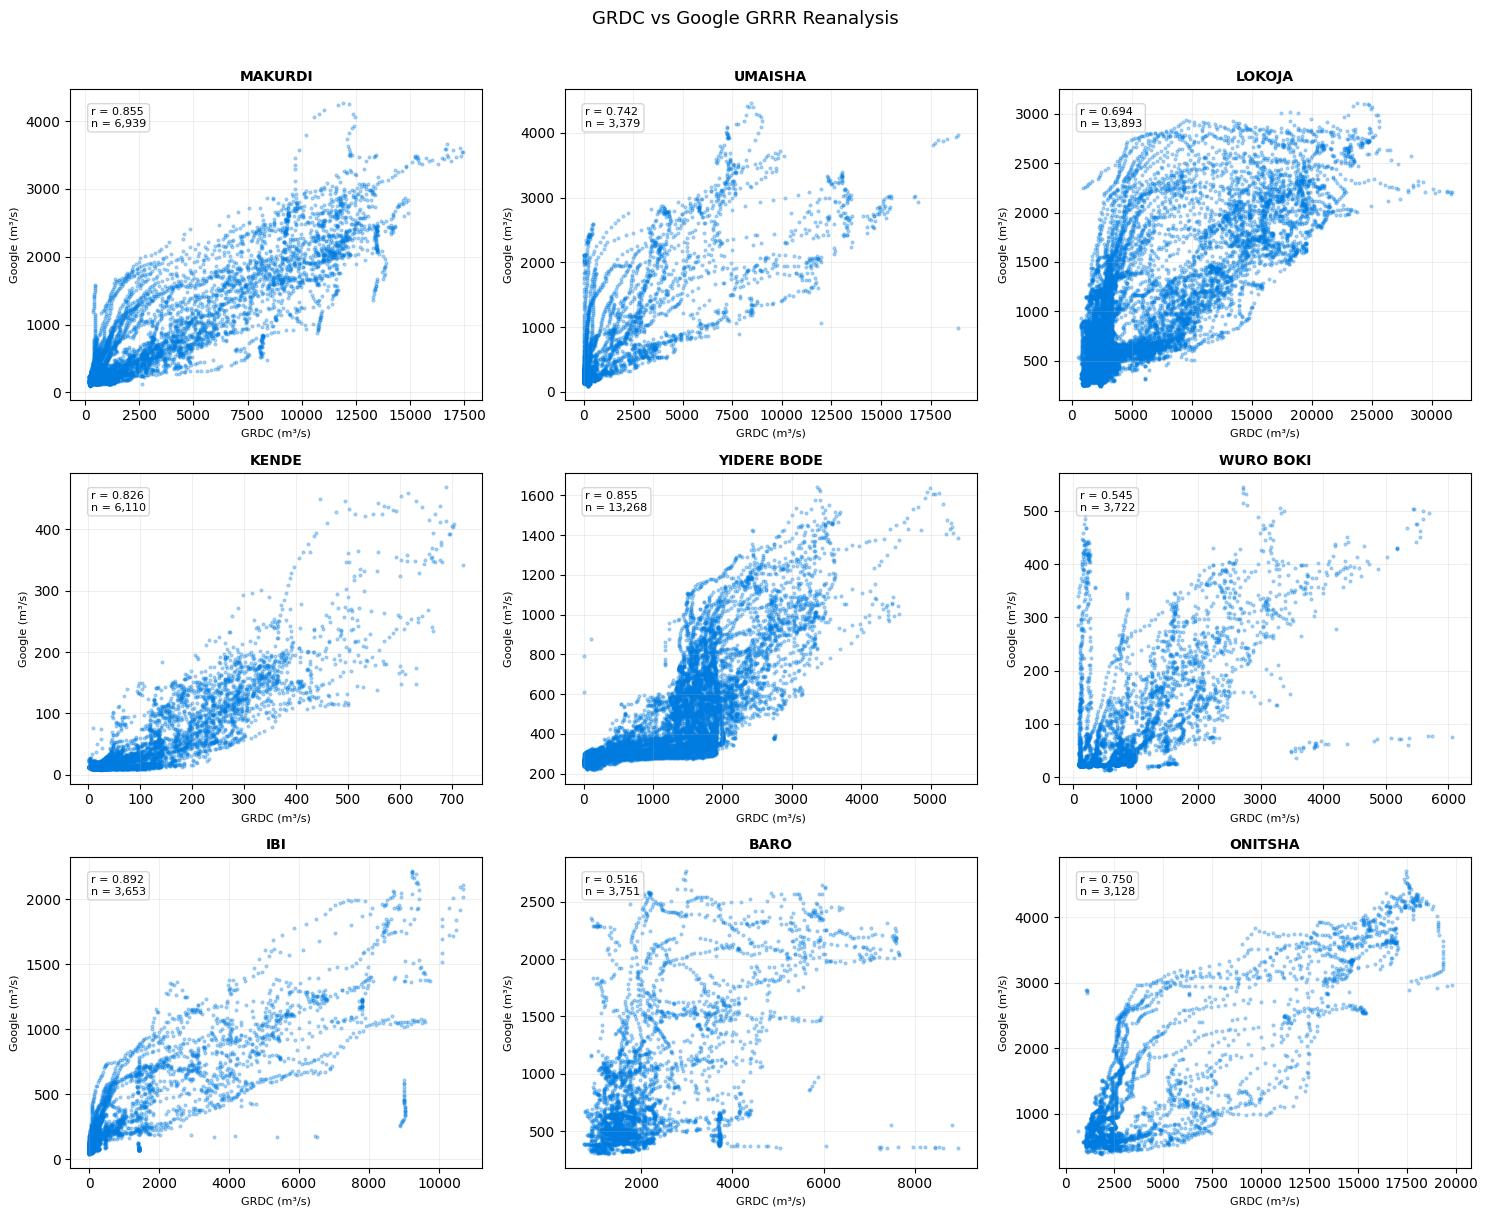

In [171]:
# 3×3 scatter plots of actual discharge values, annotated with Spearman r
n = len(pair_data)
ncols = 3
nrows = int(np.ceil(n / ncols))

ordered_grdc_ids = [gid for gid in gauge_mapping if gid in pair_data]

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, grdc_id in enumerate(ordered_grdc_ids):
    ax = axes[i]
    merged = pair_data[grdc_id]
    station = name_lookup.get(grdc_id, str(grdc_id))
    row = df_corr[df_corr["grdc_id"] == grdc_id].iloc[0]

    ax.scatter(merged["grdc_q"], merged["streamflow"], s=4, alpha=0.3, color="#007CE0", rasterized=True)

    ax.set_title(station, fontsize=10, fontweight="bold")
    ax.set_xlabel("GRDC (m³/s)", fontsize=8)
    ax.set_ylabel("Google (m³/s)", fontsize=8)
    ax.annotate(f"r = {row['spearman_r']:.3f}\nn = {row['n_days']:,}",
                xy=(0.05, 0.88), xycoords="axes fraction", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc", alpha=0.8))
    ax.grid(True, alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("GRDC vs Google GRRR Reanalysis", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/grdc_google_comparison.png", dpi=300)

## Peak event comparison

For each gauge pair, compute wet-season (Jul–Nov) annual maxima and empirical 1-in-3 and 1-in-5 year thresholds independently from each dataset. Then compare which years each flags as exceedance events.

In [172]:
WET_SEASON_MONTHS = [7, 8, 9, 10, 11]
PEAK_MONTHS = [8, 9, 10]       # months checked for consecutive gaps
MIN_WET_OBS = 120              # min wet-season obs per year (out of ~153)
MAX_PEAK_GAP_DAYS = 14         # max consecutive missing days allowed in peak months
MIN_VALID_YEARS = 15           # min valid years for station to be included
RETURN_PERIODS = [3, 5]


def year_has_peak_gap(grdc_ws_year):
    """Return True if a year has a consecutive gap > MAX_PEAK_GAP_DAYS in peak months."""
    peak = grdc_ws_year[grdc_ws_year["date"].dt.month.isin(PEAK_MONTHS)][["date", "grdc_q"]]
    if peak.empty:
        return True
    full_range = pd.date_range(peak["date"].min(), peak["date"].max(), freq="D")
    observed = set(peak.dropna(subset=["grdc_q"])["date"])
    max_gap = 0
    gap = 0
    for d in full_range:
        if d not in observed:
            gap += 1
            max_gap = max(max_gap, gap)
        else:
            gap = 0
    return max_gap > MAX_PEAK_GAP_DAYS


def empirical_rp_thresholds(annual_maxima, return_periods):
    """Return empirical quantile thresholds for each return period.
    Uses the quantile 1 - 1/rp directly from observed annual maxima.
    """
    return {rp: annual_maxima.quantile(1 - 1 / rp) for rp in return_periods}


peak_data = {}
skipped = []
# valid_years for every station (including skipped), used for time series shading
station_valid_years = {}

for grdc_id, google_id in gauge_mapping.items():
    if grdc_id not in pair_data:
        continue
    station = name_lookup.get(grdc_id, str(grdc_id))

    grdc_ws = df_grdc[
        (df_grdc["grdc_id"] == grdc_id) &
        (df_grdc["date"].dt.month.isin(WET_SEASON_MONTHS))
    ].copy()
    grdc_ws["year"] = grdc_ws["date"].dt.year

    obs_per_year = grdc_ws.groupby("year")["grdc_q"].count()
    years_min_obs = set(obs_per_year[obs_per_year >= MIN_WET_OBS].index)

    years_no_gap = set()
    for year, group in grdc_ws.groupby("year"):
        if year in years_min_obs and not year_has_peak_gap(group):
            years_no_gap.add(year)

    valid_years = sorted(years_no_gap)
    grdc_ws_valid = grdc_ws[grdc_ws["year"].isin(valid_years)].dropna(subset=["grdc_q"])

    # Store valid years for all stations so the time series plot can shade excluded years
    all_grdc_years = set(grdc_ws["year"].unique())
    station_valid_years[grdc_id] = {
        "valid": set(valid_years),
        "all_wet_season": all_grdc_years,
    }

    if len(valid_years) < MIN_VALID_YEARS:
        skipped.append(f"{station}: {len(valid_years)} valid years (need {MIN_VALID_YEARS})")
        continue

    google_ws = df_ra[
        (df_ra["gauge_id"] == google_id) &
        (df_ra["date"].dt.month.isin(WET_SEASON_MONTHS))
    ].copy()
    google_ws["year"] = google_ws["date"].dt.year

    grdc_ann = grdc_ws_valid.groupby("year")["grdc_q"].max().reset_index(name="grdc_max")
    google_ann = google_ws.groupby("year")["streamflow"].max().reset_index(name="google_max")

    grdc_thresh = empirical_rp_thresholds(grdc_ann["grdc_max"], RETURN_PERIODS)
    google_thresh = empirical_rp_thresholds(google_ann["google_max"], RETURN_PERIODS)

    ann = grdc_ann.merge(google_ann, on="year", how="inner")
    for rp in RETURN_PERIODS:
        ann[f"grdc_exceed_{rp}yr"] = ann["grdc_max"] >= grdc_thresh[rp]
        ann[f"google_exceed_{rp}yr"] = ann["google_max"] >= google_thresh[rp]

    ann["grdc_norm"] = ann["grdc_max"] / grdc_thresh[3]
    ann["google_norm"] = ann["google_max"] / google_thresh[3]

    peak_data[grdc_id] = dict(
        station=station, ann=ann,
        grdc_thresh=grdc_thresh, google_thresh=google_thresh,
        grdc_5yr_norm=grdc_thresh[5] / grdc_thresh[3],
        google_5yr_norm=google_thresh[5] / google_thresh[3],
        n_valid_years=len(valid_years),
    )

print(f"Stations included: {len(peak_data)}")
for d in peak_data.values():
    print(f"  {d['station']}: {d['n_valid_years']} valid years")
if skipped:
    print(f"\nStations skipped:")
    for s in skipped:
        print(f"  {s}")

Stations included: 5
  MAKURDI: 15 valid years
  LOKOJA: 49 valid years
  KENDE: 18 valid years
  YIDERE BODE: 37 valid years
  IBI: 15 valid years

Stations skipped:
  UMAISHA: 9 valid years (need 15)
  WURO BOKI: 9 valid years (need 15)
  BARO: 8 valid years (need 15)
  ONITSHA: 7 valid years (need 15)


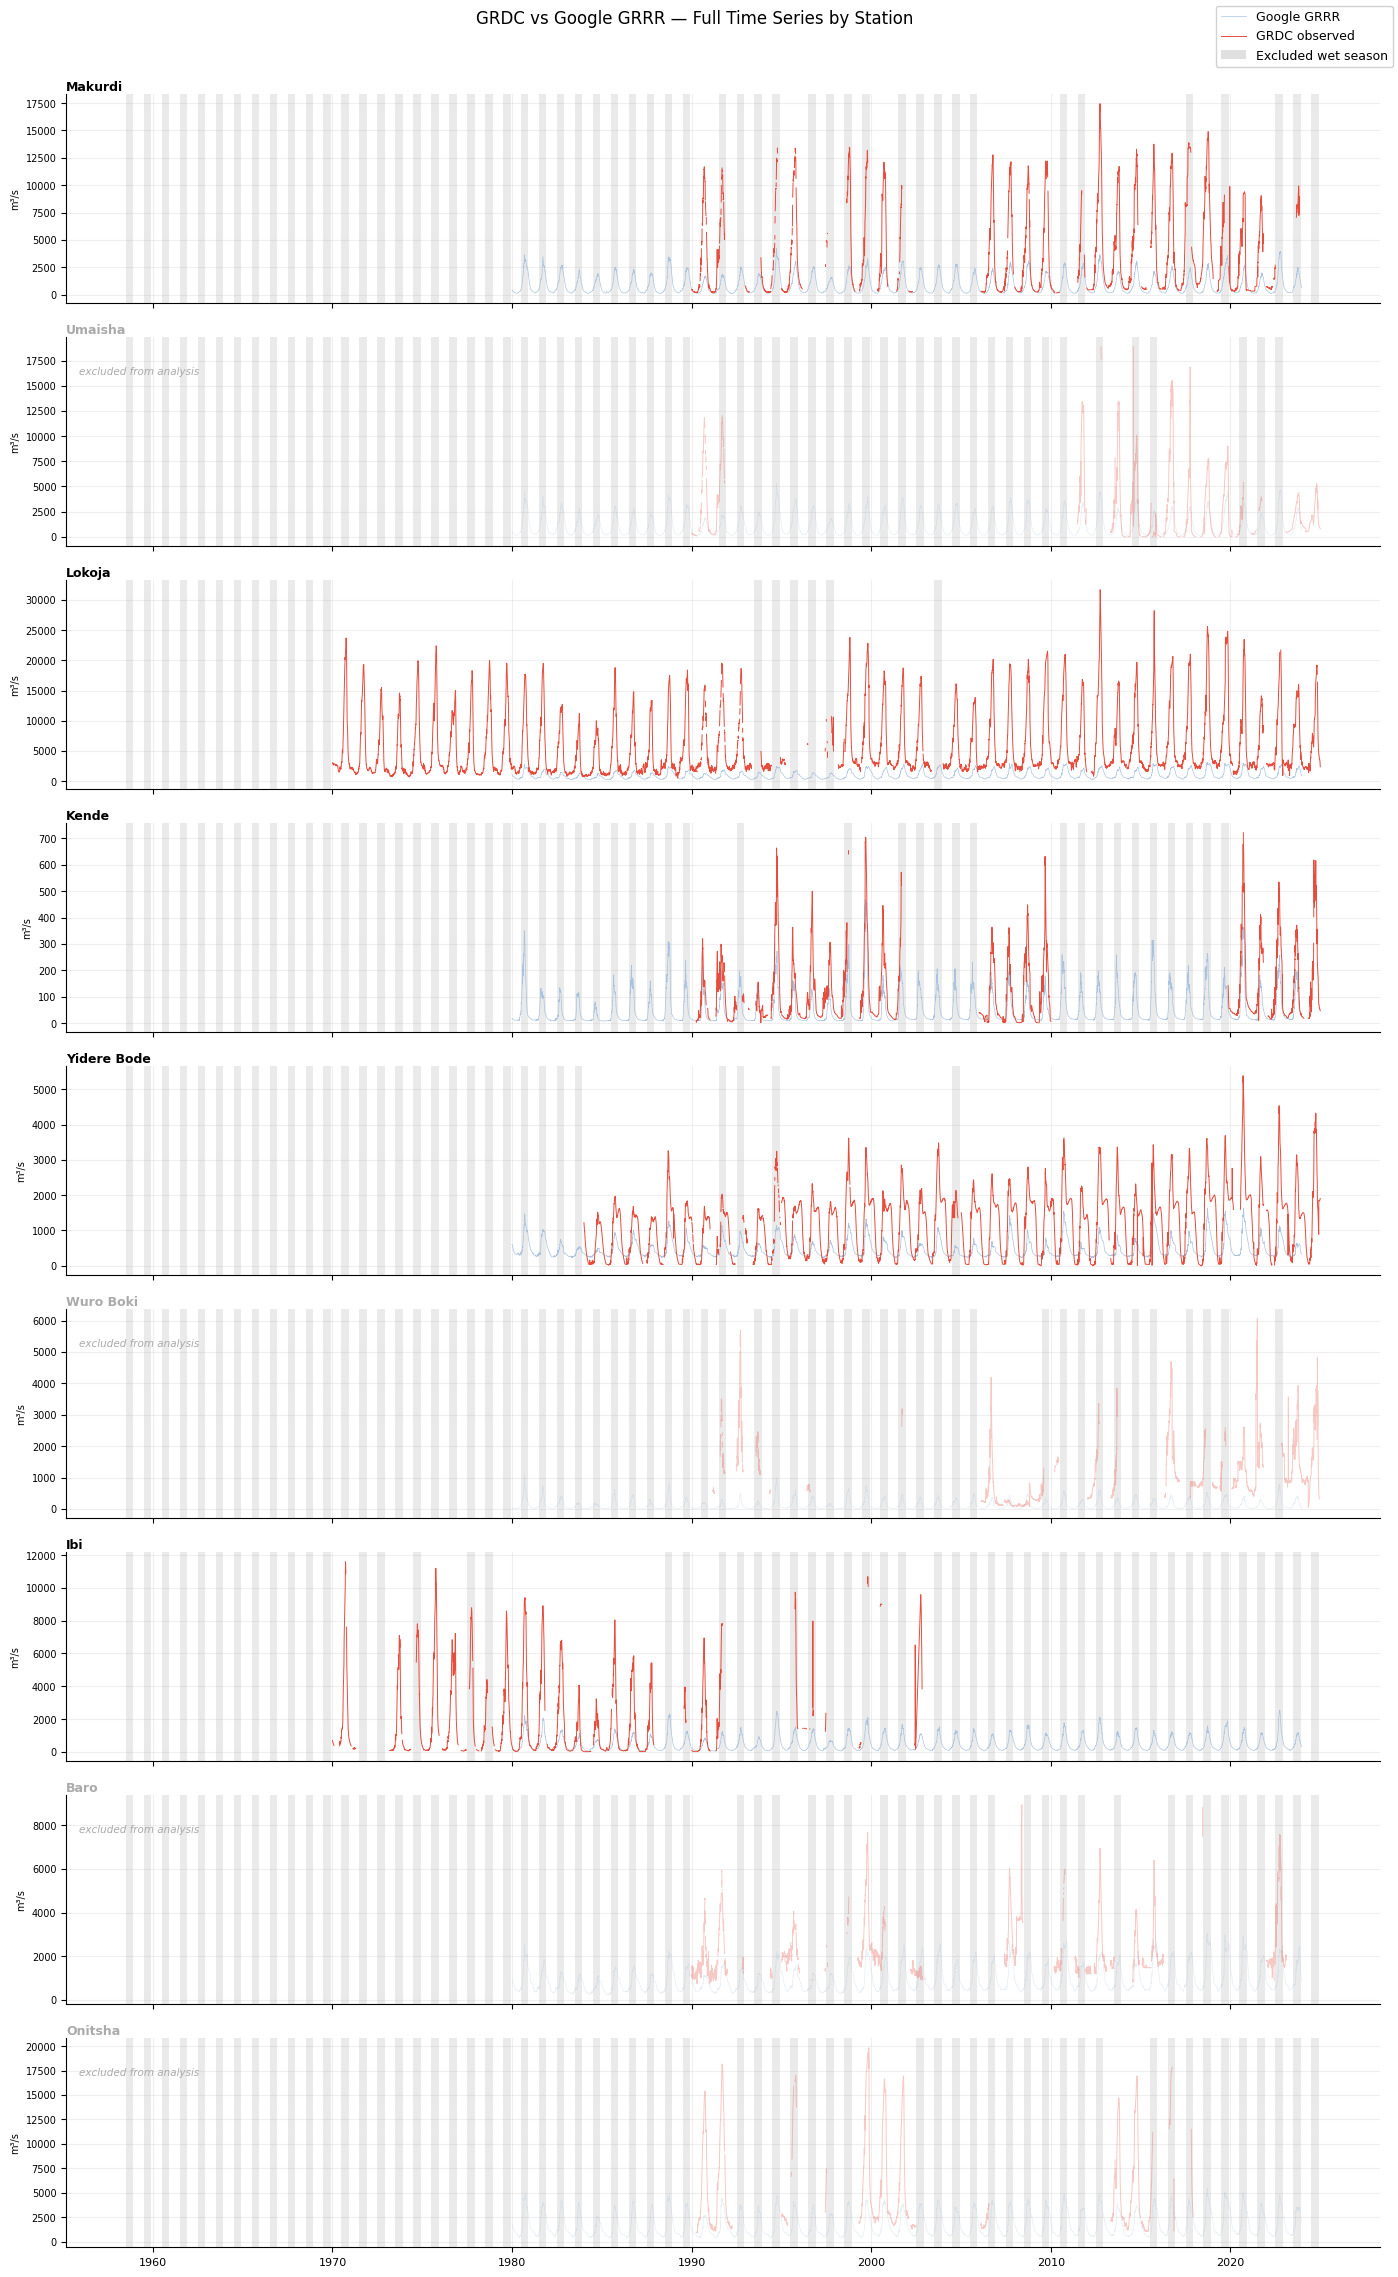

In [173]:
# All stations as subplot rows with shared x-axis to compare temporal coverage.
# Stations excluded from the peak analysis are greyed out and labelled.
# Grey bands mark wet seasons (Jul–Nov) of years excluded by the coverage filters.
n_stations = len(gauge_mapping)
fig, axes = plt.subplots(n_stations, 1, figsize=(14, 2.5 * n_stations), sharex=True)

for i, (grdc_id, google_id) in enumerate(gauge_mapping.items()):
    ax = axes[i]
    station = name_lookup.get(grdc_id, str(grdc_id))
    excluded = grdc_id not in peak_data

    grdc_ts = df_grdc[df_grdc["grdc_id"] == grdc_id][["date", "grdc_q"]]
    google_ts = df_ra[df_ra["gauge_id"] == google_id][["date", "streamflow"]]
    ts = google_ts.merge(grdc_ts, on="date", how="outer").sort_values("date")

    # Shade wet-season windows of years that had GRDC data but failed coverage filters
    if grdc_id in station_valid_years:
        info = station_valid_years[grdc_id]
        excluded_years = info["all_wet_season"] - info["valid"]
        for year in sorted(excluded_years):
            ax.axvspan(
                pd.Timestamp(year, 7, 1), pd.Timestamp(year, 11, 30),
                facecolor="#cccccc", alpha=0.4, zorder=0, linewidth=0,
            )

    alpha = 0.3 if excluded else 1.0
    ax.plot(ts["date"], ts["streamflow"], color="#aac4e0", linewidth=0.5,
            alpha=alpha, label="Google GRRR", zorder=1)
    ax.plot(ts["date"], ts["grdc_q"], color="#e74c3c", linewidth=0.7,
            alpha=alpha, label="GRDC observed", zorder=2)

    title = station.title()
    ax.set_title(title, fontsize=9, fontweight="bold", loc="left", pad=3,
                 color="#aaaaaa" if excluded else "black")
    if excluded:
        ax.annotate(
            "excluded from analysis",
            xy=(0.01, 0.82), xycoords="axes fraction",
            fontsize=7.5, color="#aaaaaa", style="italic",
        )

    ax.set_ylabel("m³/s", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].tick_params(axis="x", labelsize=8)
handles, labels = axes[0].get_legend_handles_labels()
from matplotlib.patches import Patch
handles += [Patch(facecolor="#cccccc", alpha=0.6, label="Excluded wet season")]
labels += ["Excluded wet season"]
fig.legend(handles, labels, loc="upper right", fontsize=9, framealpha=0.9)
fig.suptitle("GRDC vs Google GRRR — Full Time Series by Station", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("figures/grdc_google_full_timeseries.png", dpi=300)

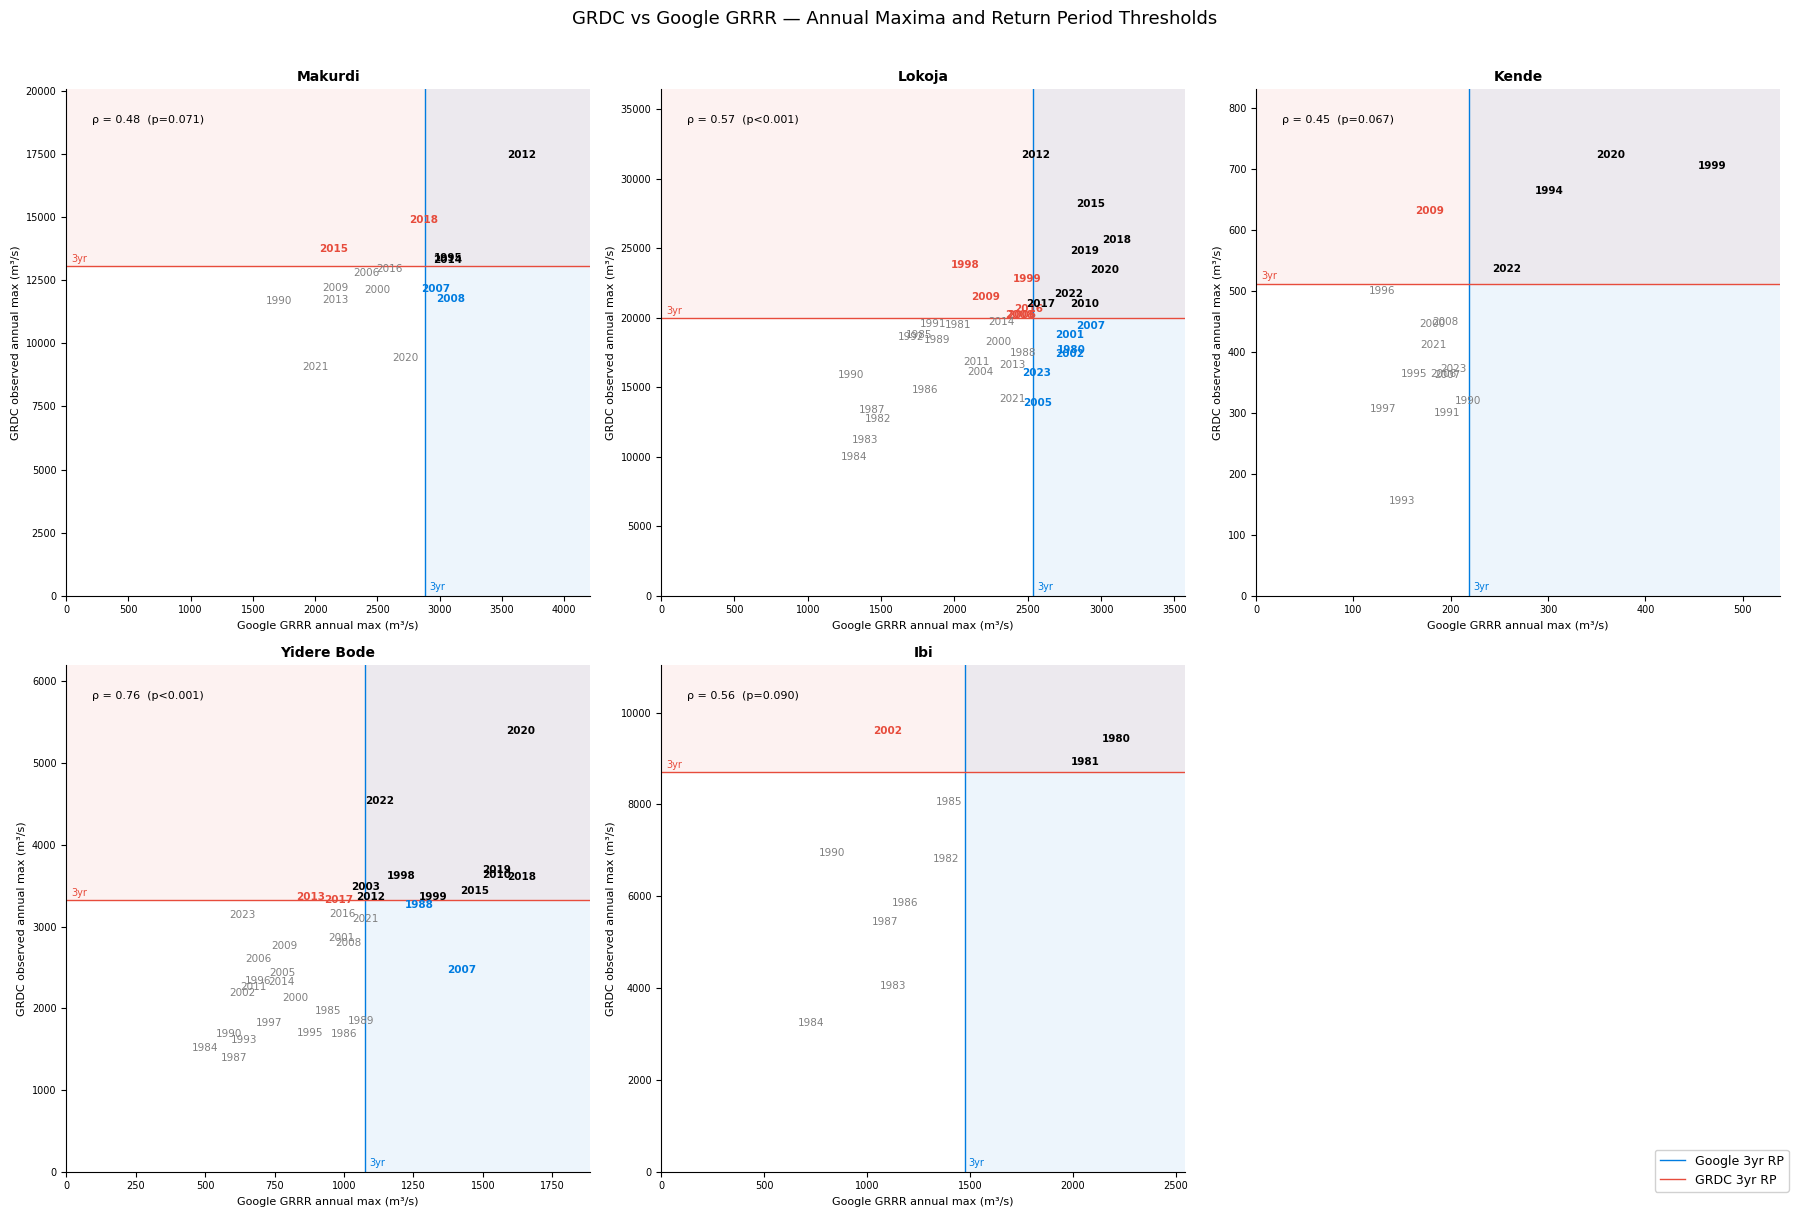

In [174]:
from scipy.stats import spearmanr

grdc_color = "#e74c3c"
google_color = "#007CE0"

ncols = 3
nrows = int(np.ceil(len(peak_data) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
axes = axes.flatten()

for i, (grdc_id, d) in enumerate(peak_data.items()):
    ax = axes[i]
    ann = d["ann"]
    grdc_thresh = d["grdc_thresh"]
    google_thresh = d["google_thresh"]

    xmax = ann["google_max"].max() * 1.15
    ymax = ann["grdc_max"].max() * 1.15

    # Threshold lines and shaded regions — 3yr (solid) and 5yr (dashed)
    for rp, ls in [(3, "-")]:
        ax.axvline(google_thresh[rp], color=google_color, linewidth=1, linestyle=ls)
        ax.axhline(grdc_thresh[rp], color=grdc_color, linewidth=1, linestyle=ls)

    ax.axvspan(google_thresh[3], xmax, facecolor=google_color, alpha=0.07)
    ax.axhspan(grdc_thresh[3], ymax, facecolor=grdc_color, alpha=0.07)

    # Threshold labels
    ax.annotate(f"3yr", (google_thresh[3], 0), color=google_color,
                xytext=(3, 4), textcoords="offset points", fontsize=7)
    ax.annotate(f"3yr", (0, grdc_thresh[3]), color=grdc_color,
                xytext=(4, 3), textcoords="offset points", fontsize=7)

    # Year labels colored by exceedance of 3yr RP
    for _, row in ann.iterrows():
        g_exc = row["google_max"] >= google_thresh[3]
        r_exc = row["grdc_max"] >= grdc_thresh[3]
        if g_exc and r_exc:
            color, fw = "black", "bold"
        elif g_exc:
            color, fw = google_color, "bold"
        elif r_exc:
            color, fw = grdc_color, "bold"
        else:
            color, fw = "grey", "normal"
        ax.annotate(str(int(row["year"])), (row["google_max"], row["grdc_max"]),
                    color=color, fontweight=fw, fontsize=7.5, va="center", ha="center")

    # Spearman correlation
    rho, pval = spearmanr(ann["google_max"], ann["grdc_max"])
    p_str = f"p={pval:.3f}" if pval >= 0.001 else "p<0.001"
    ax.text(0.05, 0.95, f"ρ = {rho:.2f}  ({p_str})",
            transform=ax.transAxes, fontsize=8, va="top",
            color="black")

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Google GRRR annual max (m³/s)", fontsize=8)
    ax.set_ylabel("GRDC observed annual max (m³/s)", fontsize=8)
    ax.set_title(d["station"].title(), fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=google_color, linewidth=1, linestyle="-", label="Google 3yr RP"),
    Line2D([0], [0], color=grdc_color, linewidth=1, linestyle="-", label="GRDC 3yr RP"),
]
fig.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.9,
           bbox_to_anchor=(1.0, 0.02))

fig.suptitle("GRDC vs Google GRRR — Annual Maxima and Return Period Thresholds",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/grdc_google_annual_peak_comparison.png", dpi=300)

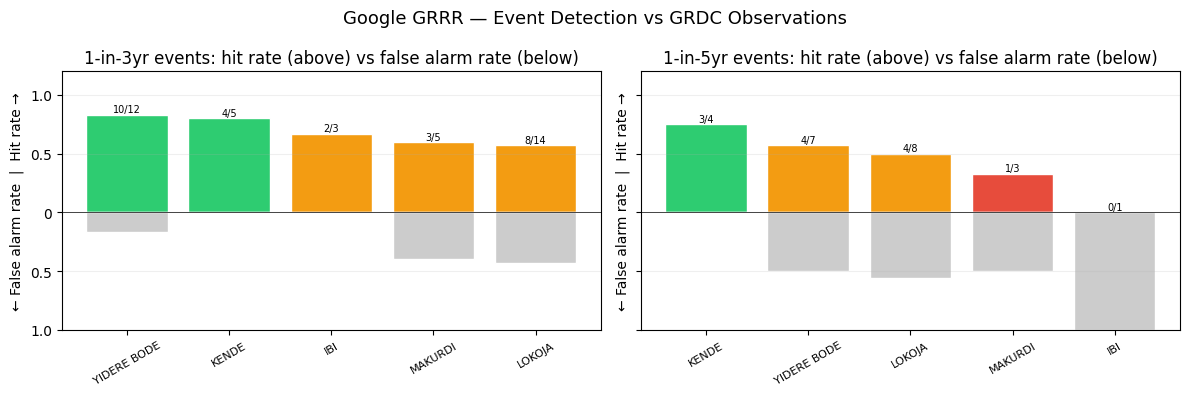

,station,rp,n_years,tp,fp,fn,tn,hit_rate,false_alarm_rate,precision,f1
0,MAKURDI,3,15,3,2,2,8,0.60,0.40,0.60,0.60
1,MAKURDI,5,15,1,1,2,11,0.33,0.50,0.50,0.40
2,LOKOJA,3,38,8,6,6,18,0.57,0.43,0.57,0.57
3,LOKOJA,5,38,4,5,4,25,0.50,0.56,0.44,0.47
4,KENDE,3,17,4,0,1,12,0.80,0.00,1.00,0.89
5,KENDE,5,17,3,0,1,13,0.75,0.00,1.00,0.86
6,YIDERE BODE,3,36,10,2,2,22,0.83,0.17,0.83,0.83
7,YIDERE BODE,5,36,4,4,3,25,0.57,0.50,0.50,0.53
8,IBI,3,10,2,0,1,7,0.67,0.00,1.00,0.80
9,IBI,5,10,0,2,1,7,0.00,1.00,0.00,NaN


In [175]:
# Event agreement summary: hit rate, false alarm rate, and F1 score per station × return period
agreement_rows = []

for grdc_id, d in peak_data.items():
    ann = d["ann"]
    for rp in RETURN_PERIODS:
        grdc_exc = ann[f"grdc_exceed_{rp}yr"]
        google_exc = ann[f"google_exceed_{rp}yr"]
        n = len(ann)
        tp = (grdc_exc & google_exc).sum()
        fp = (~grdc_exc & google_exc).sum()
        fn = (grdc_exc & ~google_exc).sum()
        tn = (~grdc_exc & ~google_exc).sum()
        hit_rate = tp / grdc_exc.sum() if grdc_exc.sum() > 0 else np.nan
        far = fp / google_exc.sum() if google_exc.sum() > 0 else np.nan
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        f1 = (2 * precision * hit_rate / (precision + hit_rate)
              if (pd.notna(precision) and pd.notna(hit_rate) and (precision + hit_rate) > 0)
              else np.nan)
        agreement_rows.append(dict(
            station=d["station"], rp=rp, n_years=n,
            tp=tp, fp=fp, fn=fn, tn=tn,
            hit_rate=round(hit_rate, 2), false_alarm_rate=round(far, 2),
            precision=round(precision, 2), f1=round(f1, 2),
        ))

df_agree = pd.DataFrame(agreement_rows)

# Plot: grouped bar chart of hit rate per station for each RP
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, rp in zip(axes, RETURN_PERIODS):
    sub = df_agree[df_agree["rp"] == rp].sort_values("hit_rate", ascending=False)
    colors = ["#2ecc71" if h >= 0.7 else "#f39c12" if h >= 0.4 else "#e74c3c"
              for h in sub["hit_rate"]]
    bars = ax.bar(sub["station"], sub["hit_rate"], color=colors, edgecolor="white")
    ax.bar(sub["station"], -sub["false_alarm_rate"], color="#cccccc", edgecolor="white",
           label="False alarm rate (Google flags, GRDC doesn't)")

    for bar, row in zip(bars, sub.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{row.tp}/{row.tp + row.fn}", ha="center", fontsize=7)

    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylim(-1, 1.2)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1.0])
    ax.set_yticklabels(["1.0", "0.5", "0", "0.5", "1.0"])
    ax.set_ylabel("← False alarm rate  |  Hit rate →")
    ax.set_title(f"1-in-{rp}yr events: hit rate (above) vs false alarm rate (below)")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(axis="y", alpha=0.2)

fig.suptitle("Google GRRR — Event Detection vs GRDC Observations", fontsize=13)
plt.tight_layout()
plt.show()

df_agree[["station", "rp", "n_years", "tp", "fp", "fn", "tn",
          "hit_rate", "false_alarm_rate", "precision", "f1"]]

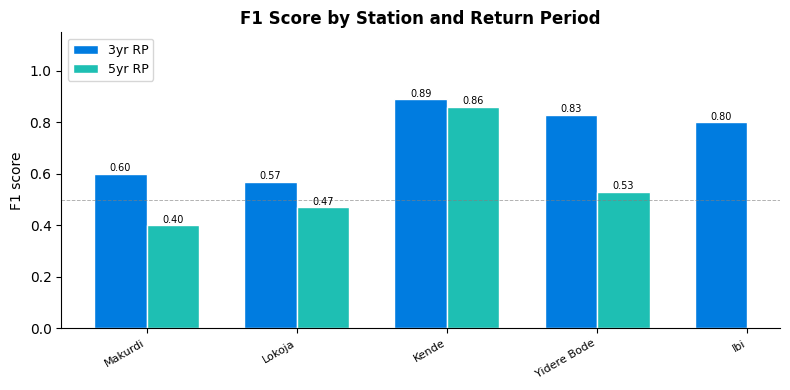

In [176]:
stations = df_agree["station"].unique()
x = np.arange(len(stations))
width = 0.35
rp_colors = {3: "#007CE0", 5: "#1EBFB3"}

fig, ax = plt.subplots(figsize=(8, 4))

for j, rp in enumerate(RETURN_PERIODS):
    sub = df_agree[df_agree["rp"] == rp].set_index("station").reindex(stations)
    offset = (j - 0.5) * width
    bars = ax.bar(x + offset, sub["f1"], width, label=f"{rp}yr RP",
                  color=rp_colors[rp], edgecolor="white")
    for bar, val in zip(bars, sub["f1"]):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([s.title() for s in stations], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.15)
ax.axhline(0.5, color="grey", linewidth=0.7, linestyle="--", alpha=0.6)
ax.legend(fontsize=9)
ax.set_title("F1 Score by Station and Return Period", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/grdc_google_f1_scores.png", dpi=300)

## Day-level timing analysis

Re-examine hits, misses, and false alarms at the day level. A **hit** is any year where both GRDC and Google exceed the 3yr RP threshold in the same wet season. For hits, the signed offset (days between first exceedance dates) is reported in the plots.

In [177]:
OUTCOME_COLORS = {
    "hit":          "#2ecc71",   # green
    "miss":         "#e74c3c",   # red   — GRDC exceeds, Google doesn't
    "false_alarm":  "#f39c12",   # orange — Google exceeds, GRDC doesn't
    "neither":      "#cccccc",   # grey
}

timing_data = {}

for grdc_id, d in peak_data.items():
    station = d["station"]
    google_id = gauge_mapping[grdc_id]
    grdc_thr = d["grdc_thresh"][3]
    google_thr = d["google_thresh"][3]

    grdc_ts = df_grdc[df_grdc["grdc_id"] == grdc_id][["date", "grdc_q"]].copy()
    google_ts = df_ra[df_ra["gauge_id"] == google_id][["date", "streamflow"]].copy()

    valid_years = set(d["ann"]["year"])

    grdc_ws = grdc_ts[grdc_ts["date"].dt.month.isin(WET_SEASON_MONTHS)].copy()
    grdc_ws["year"] = grdc_ws["date"].dt.year
    grdc_ws = grdc_ws[grdc_ws["year"].isin(valid_years)]

    google_ws = google_ts[google_ts["date"].dt.month.isin(WET_SEASON_MONTHS)].copy()
    google_ws["year"] = google_ws["date"].dt.year
    google_ws = google_ws[google_ws["year"].isin(valid_years)]

    rows = []
    for year in sorted(valid_years):
        grdc_yr = grdc_ws[grdc_ws["year"] == year].dropna(subset=["grdc_q"])
        google_yr = google_ws[google_ws["year"] == year].dropna(subset=["streamflow"])
        if grdc_yr.empty or google_yr.empty:
            continue

        # Annual peak (for plotting)
        grdc_peak_val = grdc_yr["grdc_q"].max()
        grdc_peak_date = grdc_yr.loc[grdc_yr["grdc_q"].idxmax(), "date"]
        google_peak_val = google_yr["streamflow"].max()
        google_peak_date = google_yr.loc[google_yr["streamflow"].idxmax(), "date"]

        # First exceedance date (for signed offset reporting)
        grdc_exc_dates = grdc_yr[grdc_yr["grdc_q"] >= grdc_thr]["date"]
        google_exc_dates = google_yr[google_yr["streamflow"] >= google_thr]["date"]
        grdc_first_exc = grdc_exc_dates.min() if len(grdc_exc_dates) > 0 else pd.NaT
        google_first_exc = google_exc_dates.min() if len(google_exc_dates) > 0 else pd.NaT

        grdc_exc = pd.notna(grdc_first_exc)
        google_exc = pd.notna(google_first_exc)

        if grdc_exc and google_exc:
            signed_days = (pd.Timestamp(google_first_exc) - pd.Timestamp(grdc_first_exc)).days
        else:
            signed_days = np.nan

        if grdc_exc and google_exc:
            outcome = "hit"
        elif grdc_exc:
            outcome = "miss"
        elif google_exc:
            outcome = "false_alarm"
        else:
            outcome = "neither"

        rows.append(dict(
            year=year,
            grdc_peak_val=grdc_peak_val, grdc_peak_date=grdc_peak_date,
            google_peak_val=google_peak_val, google_peak_date=google_peak_date,
            grdc_first_exc=grdc_first_exc, google_first_exc=google_first_exc,
            grdc_exc=grdc_exc, google_exc=google_exc,
            signed_days=signed_days, outcome=outcome,
        ))

    df_timing = pd.DataFrame(rows)
    counts = df_timing["outcome"].value_counts()
    timing_data[grdc_id] = dict(station=station, df=df_timing, counts=counts)

# Summary table
summary_rows = []
for grdc_id, t in timing_data.items():
    c = t["counts"]
    n = len(t["df"])
    n_grdc_exc = t["df"]["grdc_exc"].sum()
    summary_rows.append(dict(
        station=t["station"].title(),
        n_years=n,
        hits=c.get("hit", 0),
        misses=c.get("miss", 0),
        false_alarms=c.get("false_alarm", 0),
        hit_rate=round(c.get("hit", 0) / n_grdc_exc, 2) if n_grdc_exc > 0 else np.nan,
    ))

df_timing_summary = pd.DataFrame(summary_rows)
print("Timing based on first threshold exceedance date\n")
df_timing_summary

Timing based on first threshold exceedance date



,station,n_years,hits,misses,false_alarms,hit_rate
0,Makurdi,15,3,2,2,0.60
1,Lokoja,38,8,6,6,0.57
2,Kende,17,4,1,0,0.80
3,Yidere Bode,36,10,2,2,0.83
4,Ibi,10,2,1,0,0.67


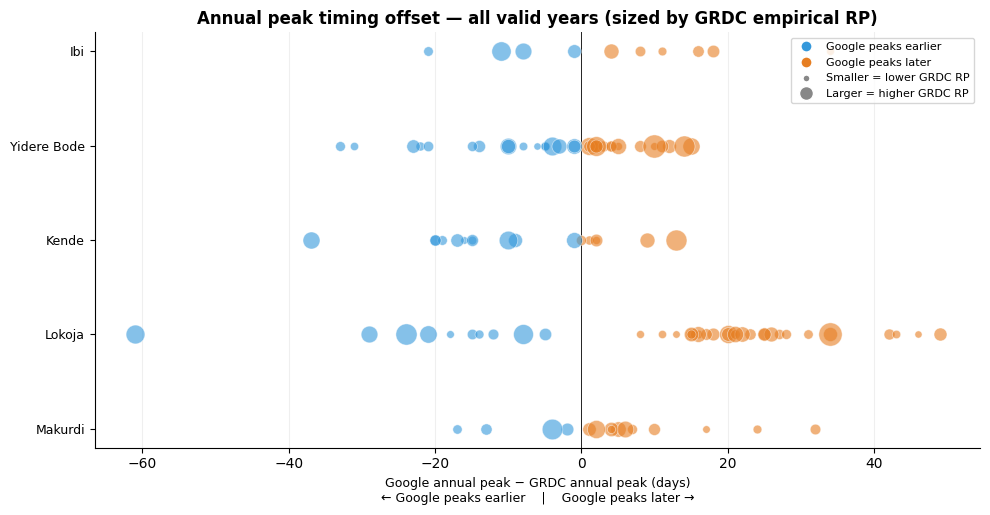

In [178]:
# Peak timing offset — all valid years, sized by GRDC empirical return period.
# x-axis: Google annual wet-season peak date minus GRDC annual wet-season peak date.
# Coloured by early (Google peaks before GRDC) or late (Google peaks after GRDC).

EARLY_COLOR = "#3498db"
LATE_COLOR  = "#e67e22"

# Compute empirical RP for each year's GRDC wet-season peak at each station
all_rows = []
for grdc_id, t in timing_data.items():
    ann = peak_data[grdc_id]["ann"][["year", "grdc_max"]].copy()
    ann_sorted = ann.sort_values("grdc_max", ascending=False).reset_index(drop=True)
    n = len(ann_sorted)
    ann_sorted["grdc_rp_emp"] = (n + 1) / np.arange(1, n + 1)
    df = t["df"].merge(ann_sorted[["year", "grdc_rp_emp"]], on="year", how="left")
    df["station"] = t["station"].title()
    all_rows.append(df)

all_years = pd.concat(all_rows, ignore_index=True)

# Peak-based signed offset (days): positive = Google peaks after GRDC
all_years["peak_signed_days"] = (
    pd.to_datetime(all_years["google_peak_date"]) -
    pd.to_datetime(all_years["grdc_peak_date"])
).dt.days

stations_ordered = [t["station"].title() for t in timing_data.values()]
y_positions = {s: i for i, s in enumerate(stations_ordered)}

def rp_to_size(rp, base=25, scale=70):
    return base + scale * np.log1p(max(float(rp) - 1, 0))

fig, ax = plt.subplots(figsize=(10, 0.75 * len(stations_ordered) + 1.5))
ax.axvline(0, color="black", linewidth=0.7, zorder=1)

for _, row in all_years.iterrows():
    y = y_positions[row["station"]]
    x = row["peak_signed_days"]
    color = EARLY_COLOR if x < 0 else LATE_COLOR
    sz = rp_to_size(row["grdc_rp_emp"] if pd.notna(row["grdc_rp_emp"]) else 1.0)
    ax.scatter(x, y, color=color, s=sz, alpha=0.6, zorder=3,
               edgecolors="white", linewidths=0.5)

ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()), fontsize=9)
ax.set_xlabel(
    "Google annual peak − GRDC annual peak (days)\n← Google peaks earlier    |    Google peaks later →",
    fontsize=9,
)
ax.set_title(
    "Annual peak timing offset — all valid years (sized by GRDC empirical RP)",
    fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="none", marker="o", markerfacecolor=EARLY_COLOR,
           markersize=8, markeredgecolor="white", label="Google peaks earlier"),
    Line2D([0], [0], color="none", marker="o", markerfacecolor=LATE_COLOR,
           markersize=8, markeredgecolor="white", label="Google peaks later"),
    Line2D([0], [0], color="none", marker="o", markerfacecolor="#888",
           markersize=5, markeredgecolor="white", label="Smaller = lower GRDC RP"),
    Line2D([0], [0], color="none", marker="o", markerfacecolor="#888",
           markersize=10, markeredgecolor="white", label="Larger = higher GRDC RP"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

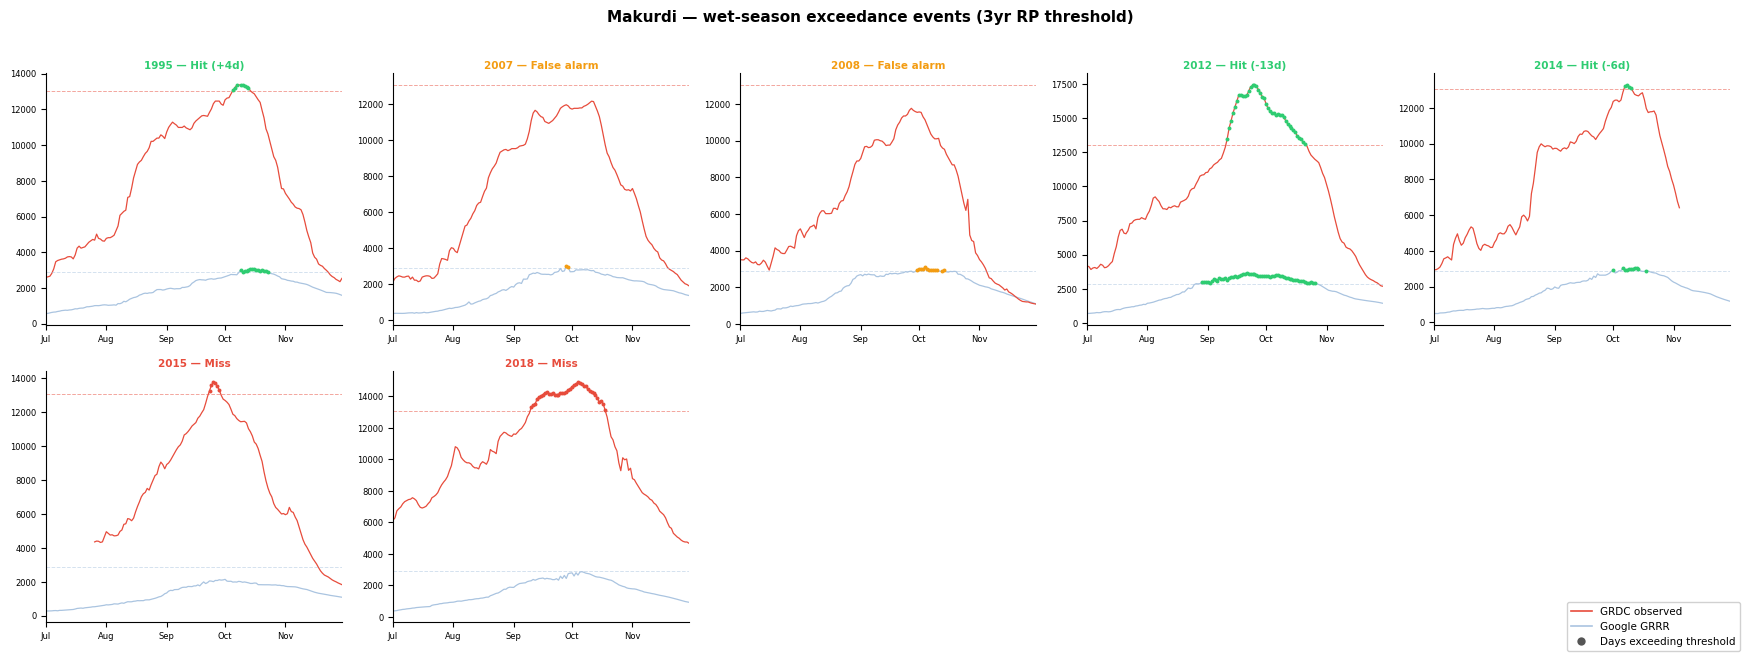

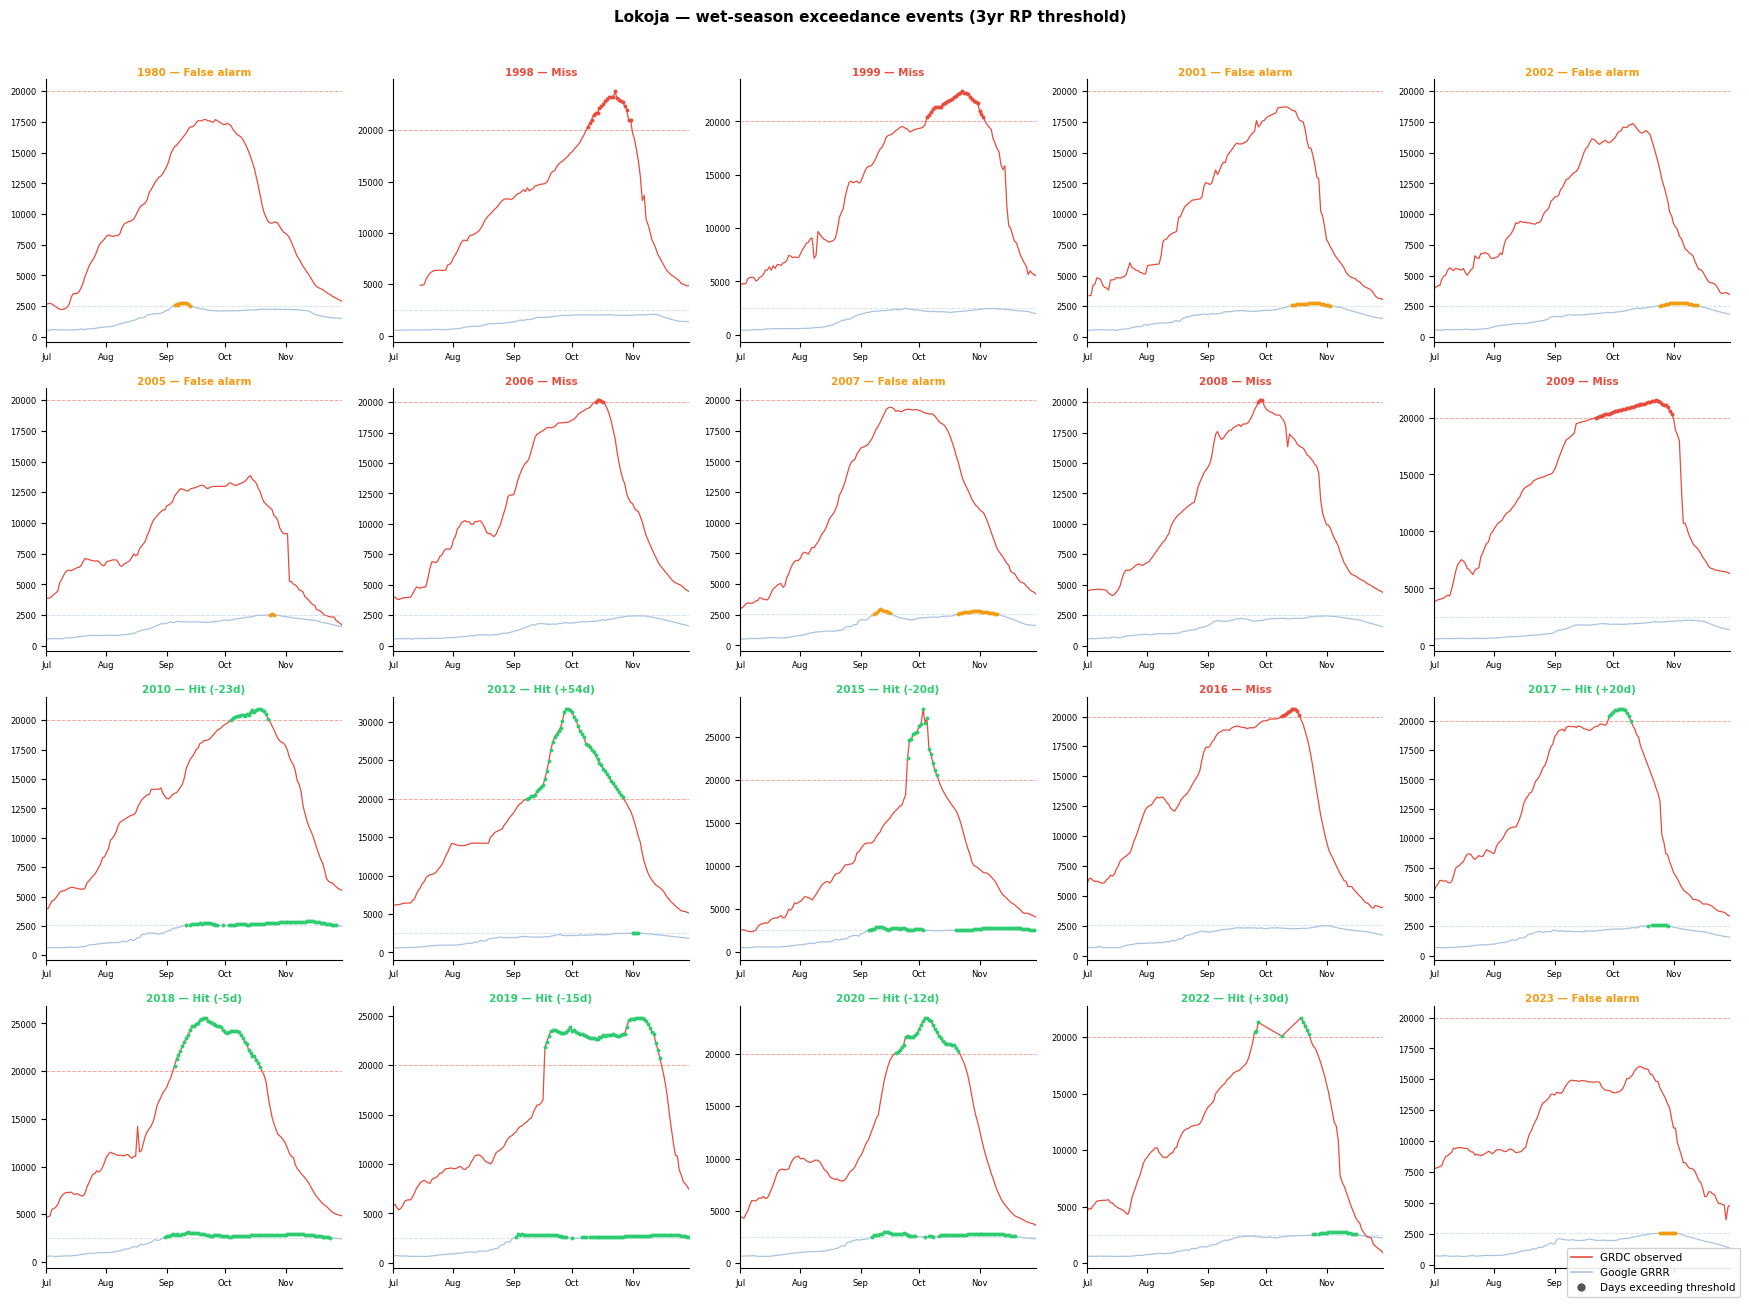

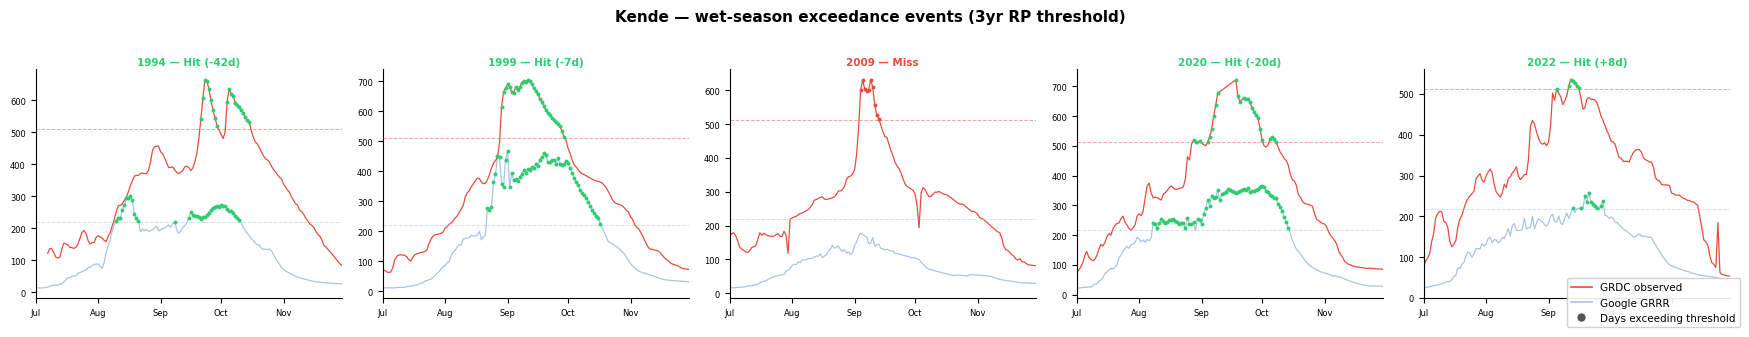

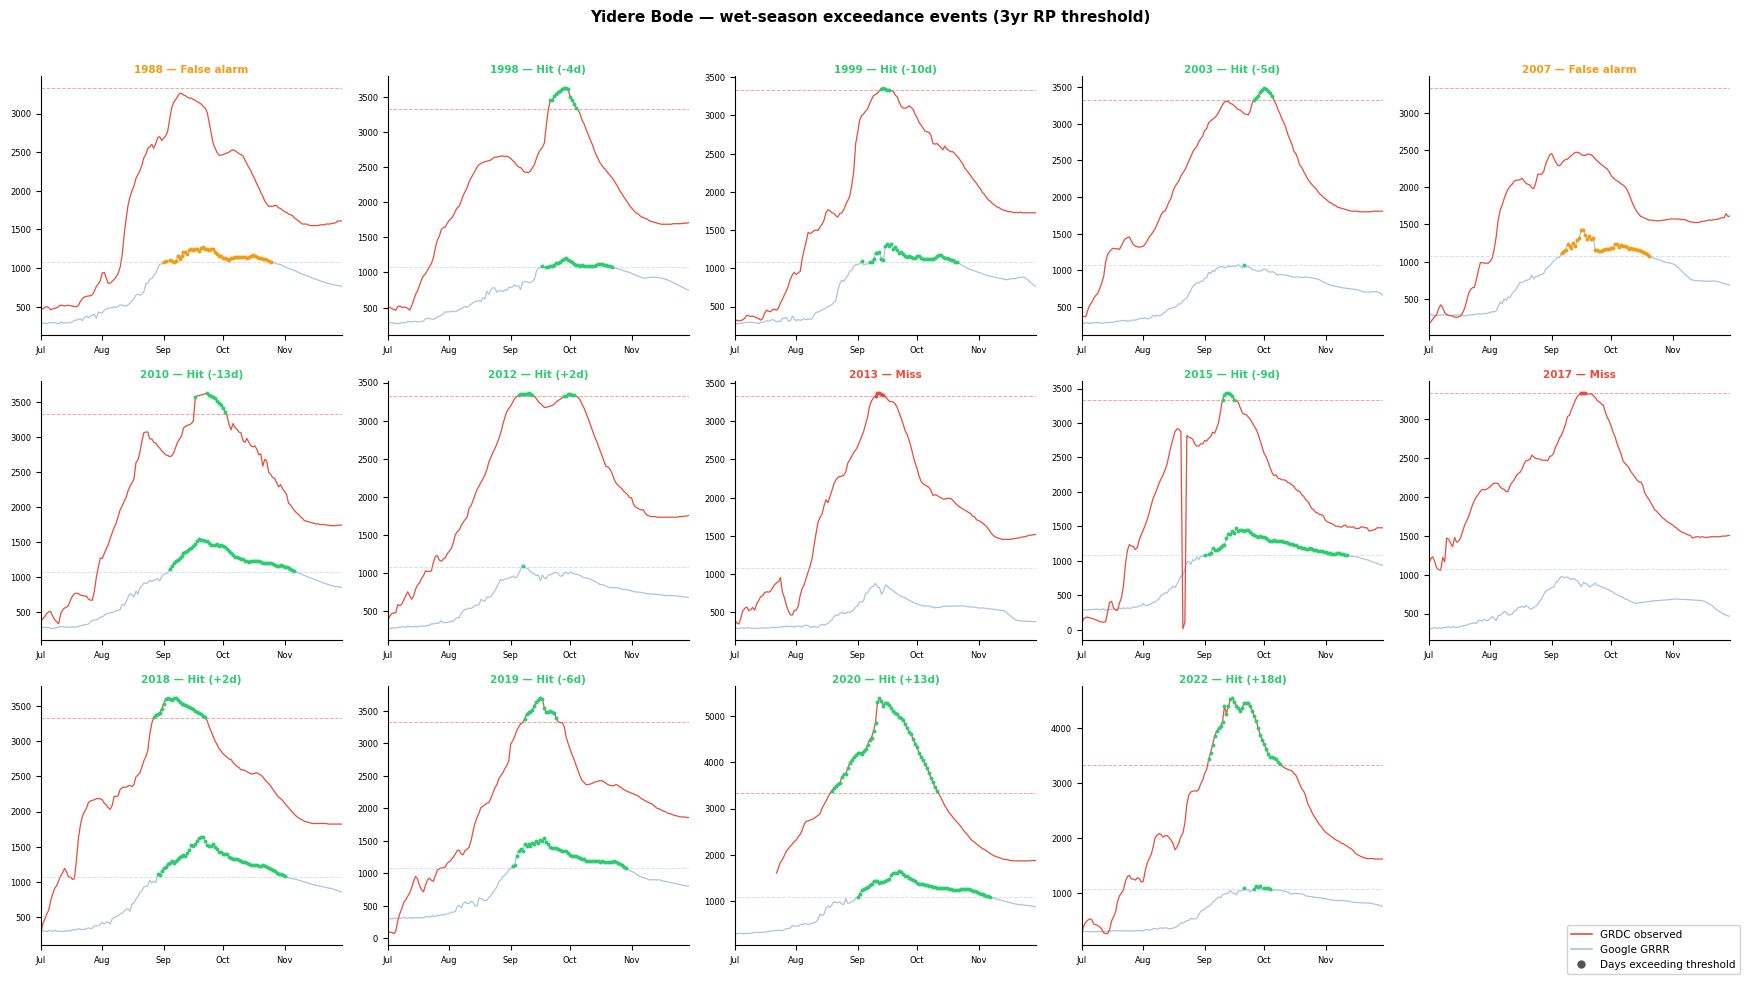

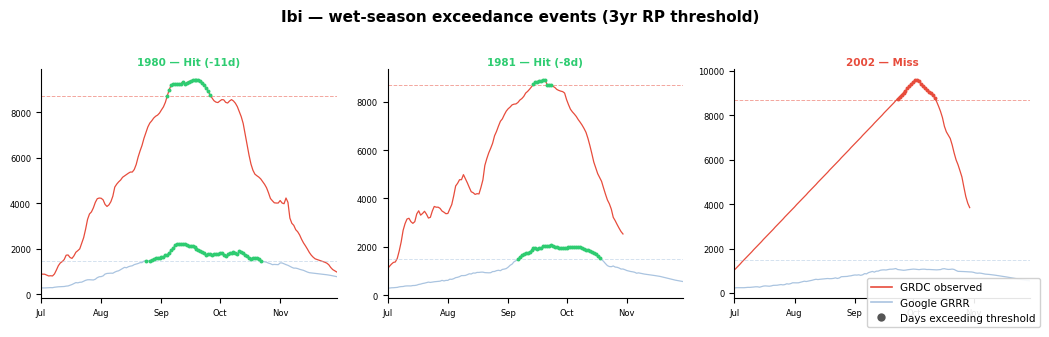

In [179]:
OUTCOME_LABELS = {
    "hit":         "Hit",
    "miss":        "Miss",
    "false_alarm": "False alarm",
}

def hit_label(signed_days):
    if pd.isna(signed_days):
        return "Hit"
    d = int(signed_days)
    return f"Hit ({'+' if d > 0 else ''}{d}d)"

# One figure per station
for grdc_id, t in timing_data.items():
    station = t["station"]
    google_id = gauge_mapping[grdc_id]
    grdc_thr = peak_data[grdc_id]["grdc_thresh"][3]
    google_thr = peak_data[grdc_id]["google_thresh"][3]

    events = t["df"][t["df"]["outcome"] != "neither"].reset_index(drop=True)
    if events.empty:
        continue

    ncols = min(5, len(events))
    nrows = int(np.ceil(len(events) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.2 * nrows))
    axes = np.array(axes).flatten()

    for i, (_, ev) in enumerate(events.iterrows()):
        ax = axes[i]
        year = int(ev["year"])
        outcome = ev["outcome"]
        color = OUTCOME_COLORS[outcome]
        label = hit_label(ev["signed_days"]) if outcome == "hit" else OUTCOME_LABELS[outcome]

        ws_start = pd.Timestamp(year, 7, 1)
        ws_end   = pd.Timestamp(year, 11, 30)

        grdc_yr = df_grdc[
            (df_grdc["grdc_id"] == grdc_id) &
            (df_grdc["date"] >= ws_start) & (df_grdc["date"] <= ws_end)
        ][["date", "grdc_q"]].dropna()
        google_yr = df_ra[
            (df_ra["gauge_id"] == google_id) &
            (df_ra["date"] >= ws_start) & (df_ra["date"] <= ws_end)
        ][["date", "streamflow"]]

        ax.plot(google_yr["date"], google_yr["streamflow"],
                color="#aac4e0", linewidth=0.9, zorder=1)
        ax.plot(grdc_yr["date"], grdc_yr["grdc_q"],
                color="#e74c3c", linewidth=0.9, zorder=2)

        # Threshold lines
        ax.axhline(grdc_thr, color="#e74c3c", linewidth=0.7, linestyle="--", alpha=0.5)
        ax.axhline(google_thr, color="#aac4e0", linewidth=0.7, linestyle="--", alpha=0.5)

        # Dots on days where each dataset exceeds its threshold
        grdc_exc_days = grdc_yr[grdc_yr["grdc_q"] >= grdc_thr]
        google_exc_days = google_yr[google_yr["streamflow"] >= google_thr]
        if not grdc_exc_days.empty:
            ax.scatter(grdc_exc_days["date"], grdc_exc_days["grdc_q"],
                       color=color, s=8, zorder=4, linewidths=0)
        if not google_exc_days.empty:
            ax.scatter(google_exc_days["date"], google_exc_days["streamflow"],
                       color=color, s=8, zorder=4, linewidths=0)

        ax.set_title(f"{year} — {label}", fontsize=7.5, fontweight="bold",
                     color=color, pad=3)
        ax.tick_params(labelsize=6)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
        ax.set_xlim(ws_start, ws_end)
        ax.spines[["top", "right"]].set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="#e74c3c", linewidth=1.2, label="GRDC observed"),
        Line2D([0], [0], color="#aac4e0", linewidth=1.2, label="Google GRRR"),
        Line2D([0], [0], color="none", marker="o", markerfacecolor="#555",
               markersize=6, markeredgewidth=0, label="Days exceeding threshold"),
    ]
    fig.legend(handles=legend_elements, loc="lower right", fontsize=7.5,
               framealpha=0.9, bbox_to_anchor=(1.0, 0.0))
    fig.suptitle(
        f"{station.title()} — wet-season exceedance events (3yr RP threshold)",
        fontsize=11, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.savefig(f"figures/grdc_google_events_{station.lower().replace(' ', '_')}.png",
                dpi=200, bbox_inches="tight")
    plt.show()